In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

In [3]:
cmap_map = 'plasma'

# Load data from local machine

In [4]:
fn_gcatlo = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock1.fits'
fn_gcathi = f'../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20.5/mock_catalog_quaia_G20.5_mock1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

In [5]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
name_catalog = '$Gaia$-$unWISE$ Quasar Mock Catalog'
abbrv_catalog = 'Quaia'

In [8]:
G_hi = 20.5
G_lo = 20.0

In [9]:
# for plotting purposes
fac_stdev = 0.5 # 1.45 # 1.5

## Quasar mock catalog

In [10]:
tab_gcatlo = Table.read(fn_gcatlo)
N_gcatlo = len(tab_gcatlo)
print(f"Number of data sources: {N_gcatlo}")

Number of data sources: 755512


In [11]:
print(tab_gcatlo.meta)

OrderedDict()


In [12]:
print(f"Column names: {tab_gcatlo.columns}")

Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>


In [13]:
tab_gcathi = Table.read(fn_gcathi)
N_gcathi = len(tab_gcathi)
print(f"Number of data sources: {N_gcathi}")

Number of data sources: 1295221


### Make map of quasar number counts

In [14]:
# mask the plane
b = 0 #20 #30
mask_type = 'selfunc' # 'selfunc' # None
c_gcatlo = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree)
mask_gcatlo = np.abs(c_gcatlo.galactic.b.value)>=b # use galactic coordinates from data 

In [15]:
selfunc_lo = hp.fitsfunc.read_map(fn_sello)

In [16]:
pixel_indices_gcatlo_mask = hp.ang2pix(NSIDE, tab_gcatlo['ra'][mask_gcatlo], tab_gcatlo['dec'][mask_gcatlo], lonlat=True)

# to do selfunc based mask
if b == 0:
    mask_gcatlo = selfunc_lo[pixel_indices_gcatlo_mask]>=0.5
    pixel_indices_gcatlo_mask = pixel_indices_gcatlo_mask[mask_gcatlo]
N_gcatlo_mask = len(tab_gcatlo['ra'][mask_gcatlo])

map_gcatlo = np.bincount(pixel_indices_gcatlo_mask, minlength=NPIX)

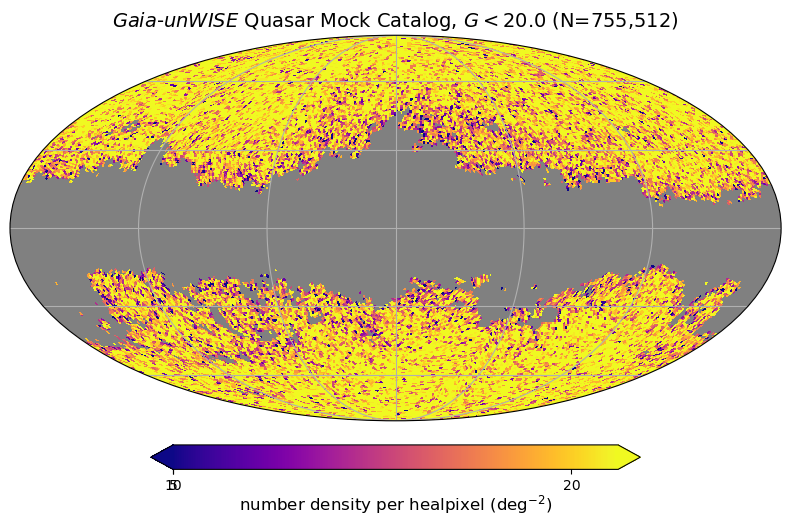

In [17]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_gcatlo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcatlo)-fac_stdev*np.std(map_gcatlo), max=np.median(map_gcatlo)+fac_stdev*np.std(map_gcatlo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20]) 

In [18]:
c_gcathi = SkyCoord(ra=tab_gcathi['ra']*u.degree, dec=tab_gcathi['dec']*u.degree)
mask_gcathi = np.abs(c_gcathi.galactic.b.value)>=b # use galactic coordinates from data 

In [19]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [20]:
pixel_indices_gcathi_mask = hp.ang2pix(NSIDE, tab_gcathi['ra'][mask_gcathi], tab_gcathi['dec'][mask_gcathi], lonlat=True)

# to do selfunc based mask
if b == 0:
    mask_gcathi = selfunc_hi[pixel_indices_gcathi_mask]>=0.5
    pixel_indices_gcathi_mask = pixel_indices_gcathi_mask[mask_gcathi]
N_gcathi_mask = len(tab_gcathi['ra'][mask_gcathi])

map_gcathi = np.bincount(pixel_indices_gcathi_mask, minlength=NPIX)

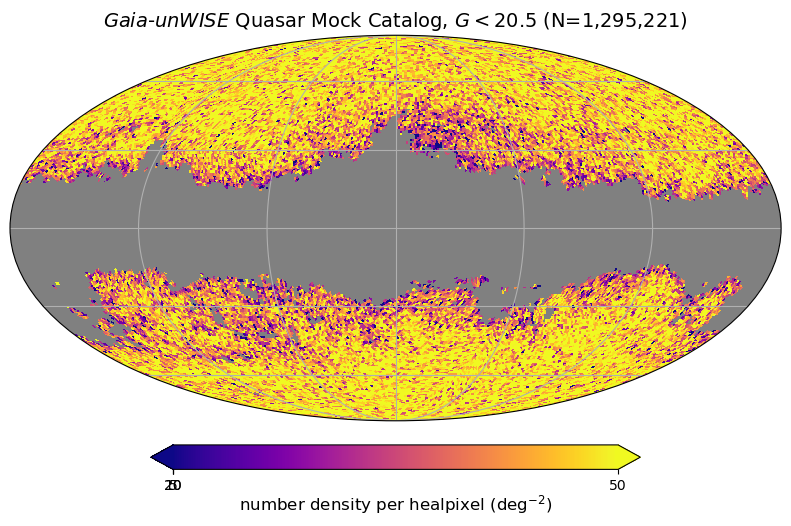

In [21]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_gcathi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_gcathi)-fac_stdev*np.std(map_gcathi), max=np.median(map_gcathi)+fac_stdev*np.std(map_gcathi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 10, 20, 50])

## Random catalog

In [22]:
tab_randlo = Table.read(fn_randlo)
N_randlo = len(tab_randlo)
print(f"Number of random sources: {N_randlo}")

Number of random sources: 7563151


In [23]:
print(f"Column names: {tab_randlo.columns}")

Column names: <TableColumns names=('ra','dec','ebv')>


In [24]:
tab_randhi = Table.read(fn_randhi)
N_randhi = len(tab_randhi)
print(f"Number of random sources: {N_randhi}")

Number of random sources: 12955802


### Make maps of random number counts

In [25]:
c_randlo = SkyCoord(ra=tab_randlo['ra'], dec=tab_randlo['dec'])
mask_randlo = np.abs(c_randlo.galactic.b.value)>=b # use galactic coordinates from data 

In [26]:
pixel_indices_randlo_mask = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo], tab_randlo['dec'][mask_randlo], lonlat=True)

# to do selfunc based mask
if b == 0:
    mask_randlo = selfunc_lo[pixel_indices_randlo_mask]>=0.5
    pixel_indices_randlo_mask = pixel_indices_randlo_mask[mask_randlo]
N_randlo_mask = len(tab_randlo['ra'][mask_randlo])

map_randlo = np.bincount(pixel_indices_randlo_mask, minlength=NPIX)

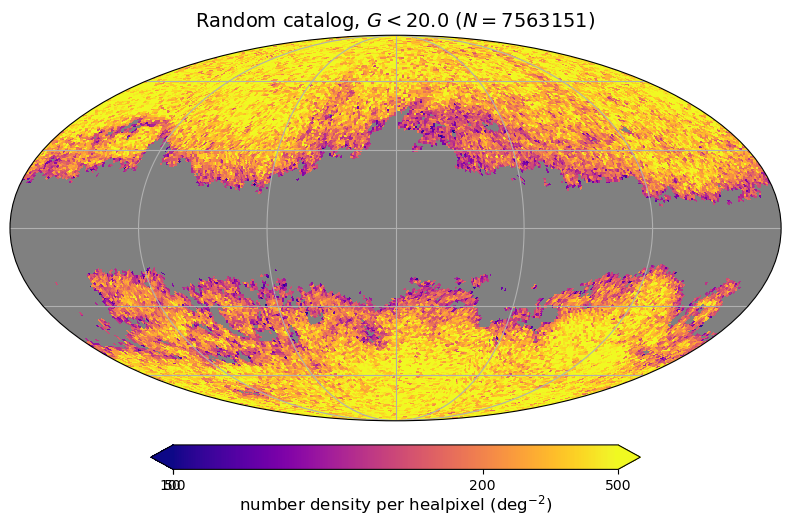

In [27]:
projview(map_randlo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randlo)-fac_stdev*np.std(map_randlo), 
            max=np.median(map_randlo)+fac_stdev*np.std(map_randlo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 100, 200, 500]) 

In [28]:
c_randhi = SkyCoord(ra=tab_randhi['ra'], dec=tab_randhi['dec'])
mask_randhi = np.abs(c_randhi.galactic.b.value)>=b # use galactic coordinates from data 

In [29]:
pixel_indices_randhi_mask = hp.ang2pix(NSIDE, tab_randhi['ra'][mask_randhi], tab_randhi['dec'][mask_randhi], lonlat=True)

# to do selfunc based mask
if b == 0:
    mask_randhi = selfunc_lo[pixel_indices_randhi_mask]>=0.5
    pixel_indices_randhi_mask = pixel_indices_randhi_mask[mask_randhi]
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])

map_randhi = np.bincount(pixel_indices_randhi_mask, minlength=NPIX)

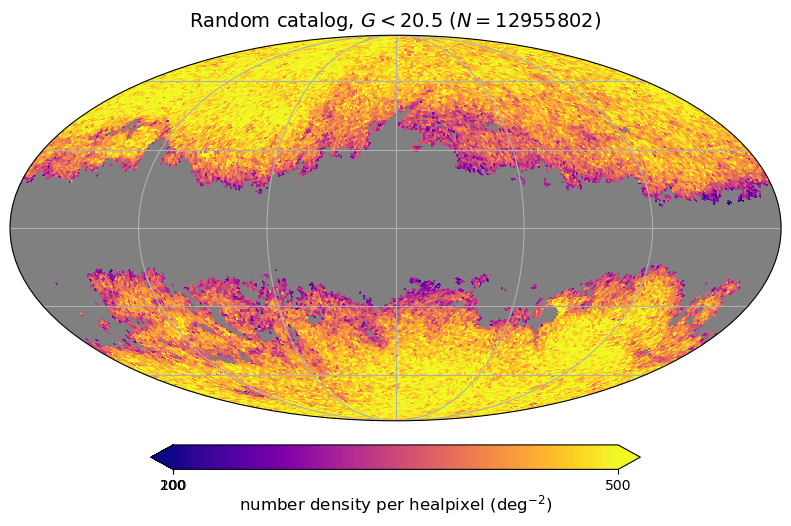

In [30]:
projview(map_randhi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.median(map_randhi)-fac_stdev*np.std(map_randhi), max=np.median(map_randhi)+fac_stdev*np.std(map_randhi), 
            norm='log', graticule=True,
            cbar_ticks=[100, 200, 500]) 

## Remove the selection function
### Start with mock catalogs

In [31]:
map_selfunc_lo = map_gcatlo/selfunc_lo

/tmp/ipykernel_100648/515644528.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


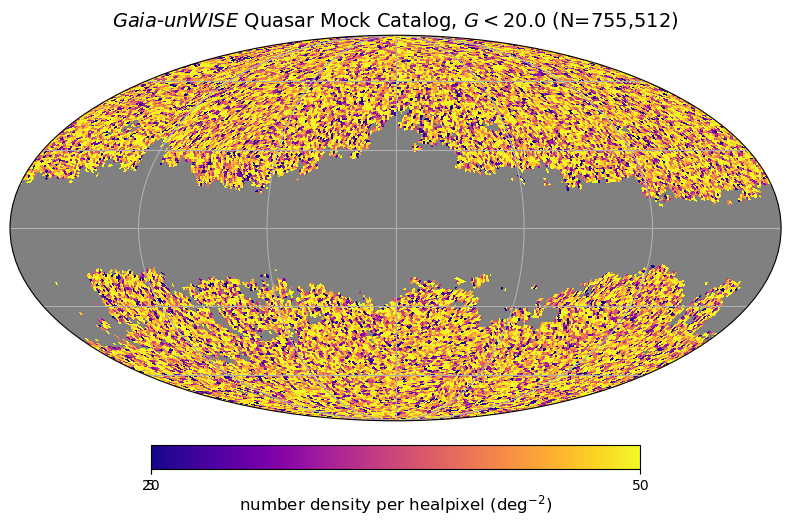

In [32]:
title_gcatlo = rf"{name_catalog}, $G<{G_lo}$ (N={len(tab_gcatlo):,})"
projview(map_selfunc_lo, title=title_gcatlo,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_selfunc_lo)-fac_stdev*np.nanstd(map_selfunc_lo), max=np.nanmedian(map_selfunc_lo)+fac_stdev*np.nanstd(map_selfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[5, 20, 50]) 

In [33]:
map_selfunc_hi = map_gcathi/selfunc_hi

/tmp/ipykernel_100648/189966545.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_hi = map_gcathi/selfunc_hi


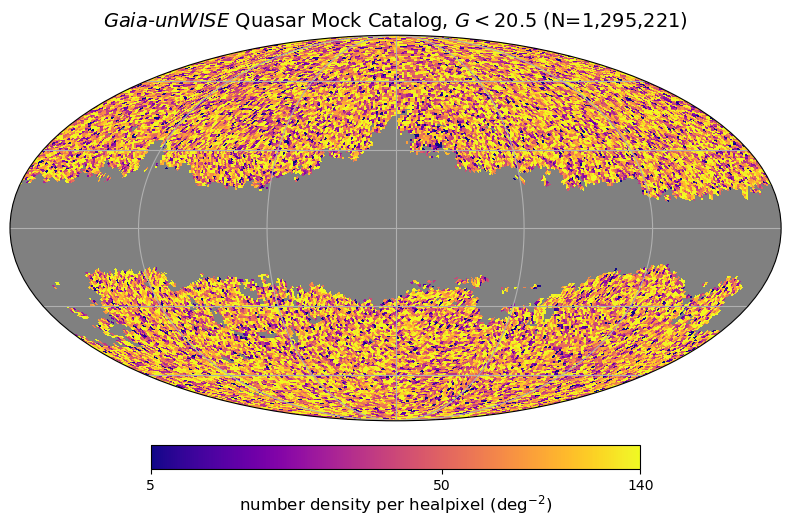

In [34]:
title_gcathi = rf"{name_catalog}, $G<{G_hi}$ (N={len(tab_gcathi):,})"
projview(map_selfunc_hi, title=title_gcathi,
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_selfunc_hi)-fac_stdev*np.nanstd(map_selfunc_hi), max=np.nanmedian(map_selfunc_hi)+fac_stdev*np.nanstd(map_selfunc_hi), 
            norm='log', graticule=True,
            cbar_ticks=[5, 50, 140]) 

### Now random catalog

In [35]:
map_randselfunc_lo = map_randlo/selfunc_lo

/tmp/ipykernel_100648/1639919514.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_lo = map_randlo/selfunc_lo


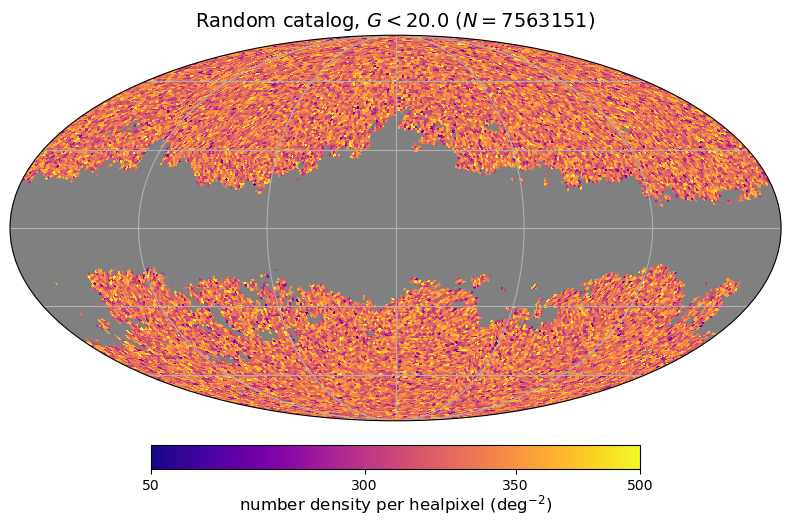

In [36]:
projview(map_randselfunc_lo, title=rf"Random catalog, $G<{G_lo}$ ($N={N_randlo}$)",
            unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
            min=np.nanmedian(map_randselfunc_lo)-fac_stdev*np.nanstd(map_randselfunc_lo), 
            max=np.nanmedian(map_randselfunc_lo)+fac_stdev*np.nanstd(map_randselfunc_lo), 
            norm='log', graticule=True,
            cbar_ticks=[50, 300, 350, 500]) 

In [37]:
map_randselfunc_hi = map_randhi/selfunc_hi

/tmp/ipykernel_100648/231715387.py:1: RuntimeWarning: invalid value encountered in true_divide
  map_randselfunc_hi = map_randhi/selfunc_hi


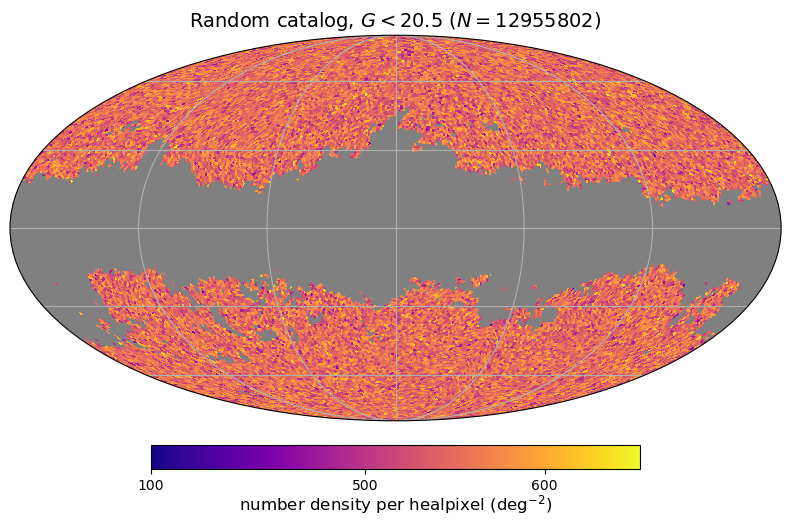

In [38]:
projview(map_randselfunc_hi, title=rf"Random catalog, $G<{G_hi}$ ($N={N_randhi}$)",
         unit=r"number density per healpixel (deg$^{-2}$)", cmap=cmap_map, coord=['C', 'G'], 
         min=np.nanmedian(map_randselfunc_hi)-fac_stdev*np.nanstd(map_randselfunc_hi), 
         max=np.nanmedian(map_randselfunc_hi)+fac_stdev*np.nanstd(map_randselfunc_hi), norm='log', graticule=True, 
         cbar_ticks=[100, 500, 600]) 

# Plot the $n(z)$ distribution

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


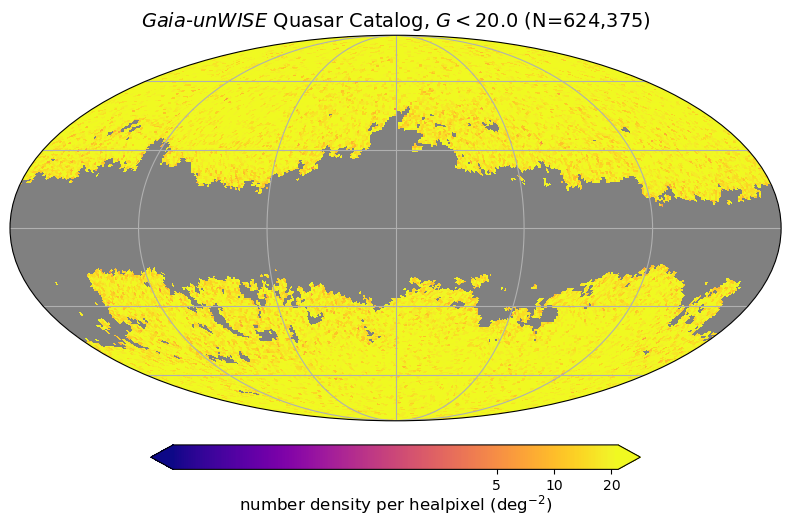

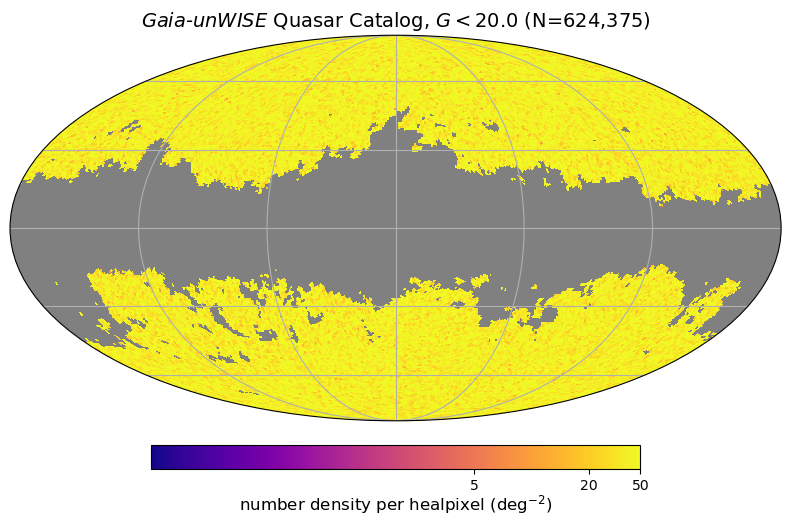

In [39]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, b = b, 
                                                                               mask_type = mask_type, selfunc_lo = selfunc_lo, plot = True, 
                                                                               fac_stdev = fac_stdev)

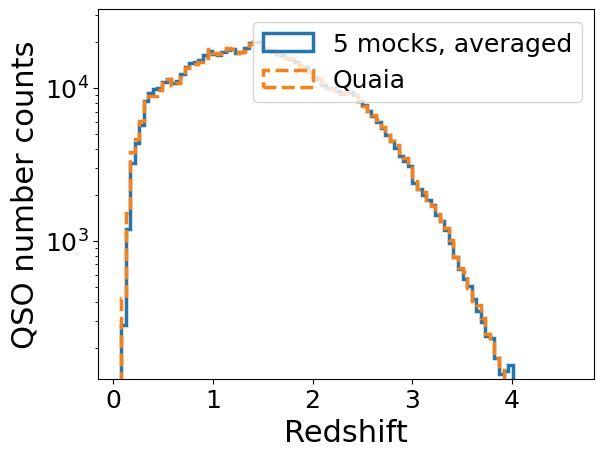

In [40]:
mean = []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,6):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i = Table.read(fn_gcatlo_i)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
plt.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', label = '5 mocks, averaged', linewidth = 2.5)
plt.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, linestyle = '--', linewidth = 2.5)
plt.xlabel('Redshift')
plt.ylabel('QSO number counts')
plt.yscale('log')
plt.ylim(125,)
plt.legend()
plt.show()

## See the impact of masking

In [41]:
mean, mean_mask = [], []
bins = np.linspace(0.08, 4.6, 100)
for i in range(1,50):

    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{:s}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, G_lo, fn_sello, b = b, 
                                                                                           mask_type = mask_type, selfunc_lo = selfunc_lo)
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'], bins = bins)
    mean.append(hist)
    
    # try it wth the mask
    hist, bin_edges = np.histogram(tab_gcatlo_i['redshift_quaia'][mask_gcatlo_i], bins = bins)
    mean_mask.append(hist)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra

/tmp/ipykernel_100648/1524820712.py:29: RuntimeWarning: invalid value encountered in true_divide
  yerr =  np.sqrt((yerr_num/num)**2 + (np.sqrt(n_mock)/n_mock)**2)*num/n_mock
/tmp/ipykernel_100648/1524820712.py:31: RuntimeWarning: invalid value encountered in true_divide
  ax2.plot(quaia.recenter(bins_data), (n_mock_mask-n_mock)/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')
/tmp/ipykernel_100648/1524820712.py:32: RuntimeWarning: invalid value encountered in true_divide
  ax2.fill_between(quaia.recenter(bins_data), y1 = num/n_mock + yerr, y2 = num/n_mock - yerr,


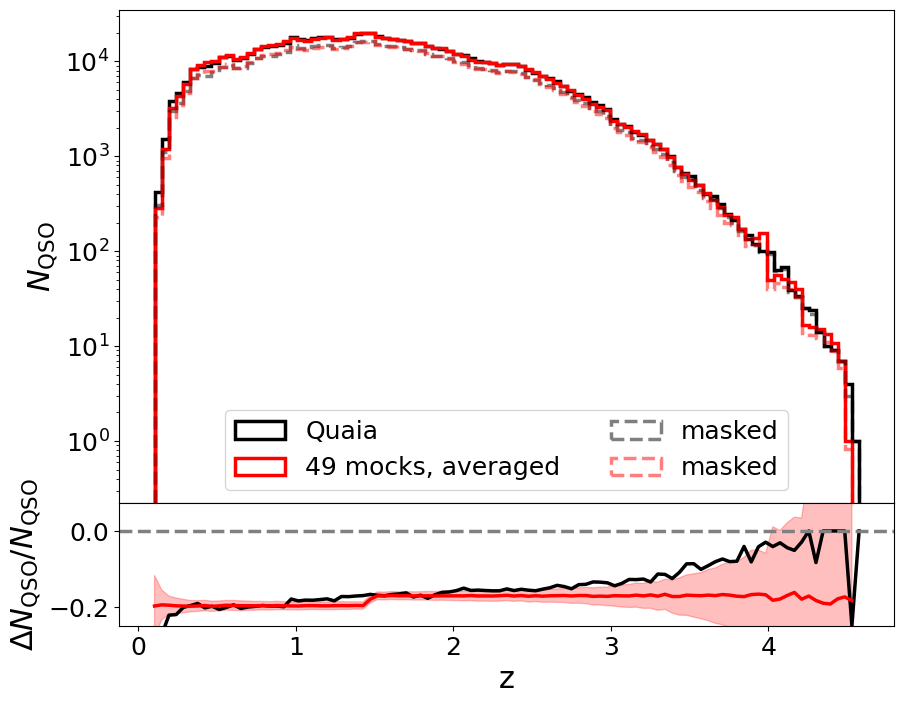

In [42]:
# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(2, 1, height_ratios = [1, 0.25], hspace = 0)

ax1 = fig.add_subplot(gs[0])
n_data, bins_data, patches_data = ax1.hist(tab_datalo['redshift_quaia'], histtype = 'step', label = 'Quaia', bins = bins, 
                                           linewidth = 2.5, color = 'black')
n_mock, bins_mock, patches_mock = ax1.hist(bins[:-1], bins, weights = np.mean(mean, axis = 0), histtype = 'step', 
                                           label = '49 mocks, averaged', linewidth = 2.5, color = 'red')
n_data_mask, bins_data_mask, patches_data_mask = ax1.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', 
                                                          label = 'masked', bins = bins, linewidth = 2.5, linestyle = '--', 
                                                          color = 'black', alpha = 0.5)
n_mock_mask, bins_mock_mask, patches_mock_mask = ax1.hist(bins[:-1], bins, weights = np.mean(mean_mask, axis = 0), histtype = 'step', 
                                                          label = 'masked', linewidth = 2.5, color = 'red', linestyle = '--', 
                                                          alpha = 0.5)
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(2.25e-1,3.5e4)
ax1.legend(ncol = 2, loc = 'lower center')
ax1.set_xticks([])

ax2 = fig.add_subplot(gs[1])
ax2.set_xlabel('z')
ax2.set_ylabel('$\Delta N_\mathrm{QSO}/N_\mathrm{QSO}$')

# relative differenc
num = n_mock_mask-n_mock
yerr_num = np.sqrt(np.sqrt(n_mock_mask)**2 + np.sqrt(n_mock)**2)
yerr =  np.sqrt((yerr_num/num)**2 + (np.sqrt(n_mock)/n_mock)**2)*num/n_mock
ax2.plot(quaia.recenter(bins_data), (n_data_mask-n_data)/n_data, label = 'Quaia', linewidth = 2.5, color = 'black')
ax2.plot(quaia.recenter(bins_data), (n_mock_mask-n_mock)/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')
ax2.fill_between(quaia.recenter(bins_data), y1 = num/n_mock + yerr, y2 = num/n_mock - yerr, 
                 label = '5 mocks, averaged', 
                 alpha = 0.25, color = 'red')
ax2.axhline(0, linestyle = '--', color = 'grey', linewidth = 2.5)
ax2.set_ylim(-0.25, 0.075)

# ratio
# yerr = np.sqrt((np.sqrt(n_mock_mask)/n_mock_mask)**2 + (np.sqrt(n_mock)/n_mock)**2)*n_mock_mask/n_mock
# ax2.plot(quaia.recenter(bins_data), n_data_mask/n_data, label = 'Quaia', linewidth = 2.5, color = 'black')
# ax2.plot(quaia.recenter(bins_data), n_mock_mask/n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')
# ax2.fill_between(quaia.recenter(bins_data), y1 = n_mock_mask/n_mock + yerr, y2 = n_mock_mask/n_mock - yerr, label = '5 mocks, averaged', 
#                  alpha = 0.25, color = 'red')
# ax2.set_ylim(0.75,1.025)

# subtraction
# yerr = np.sqrt(np.sqrt(n_mock_mask)**2 + np.sqrt(n_mock)**2)
# ax2.plot(quaia.recenter(bins_data), n_data_mask-n_data, label = 'Quaia', linewidth = 2.5, color = 'black')
# ax2.plot(quaia.recenter(bins_data), n_mock_mask-n_mock, label = '5 mocks, averaged', linewidth = 2.5, color = 'red')
# ax2.fill_between(quaia.recenter(bins_data), y1 = n_mock_mask-n_mock + yerr, y2 = n_mock_mask-n_mock - yerr, label = '5 mocks, averaged', 
#                  alpha = 0.25, color = 'red')

plt.show()

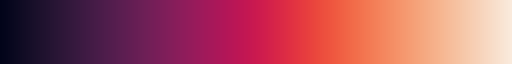

In [43]:
cmap = sns.color_palette("rocket", as_cmap = True)
cmap

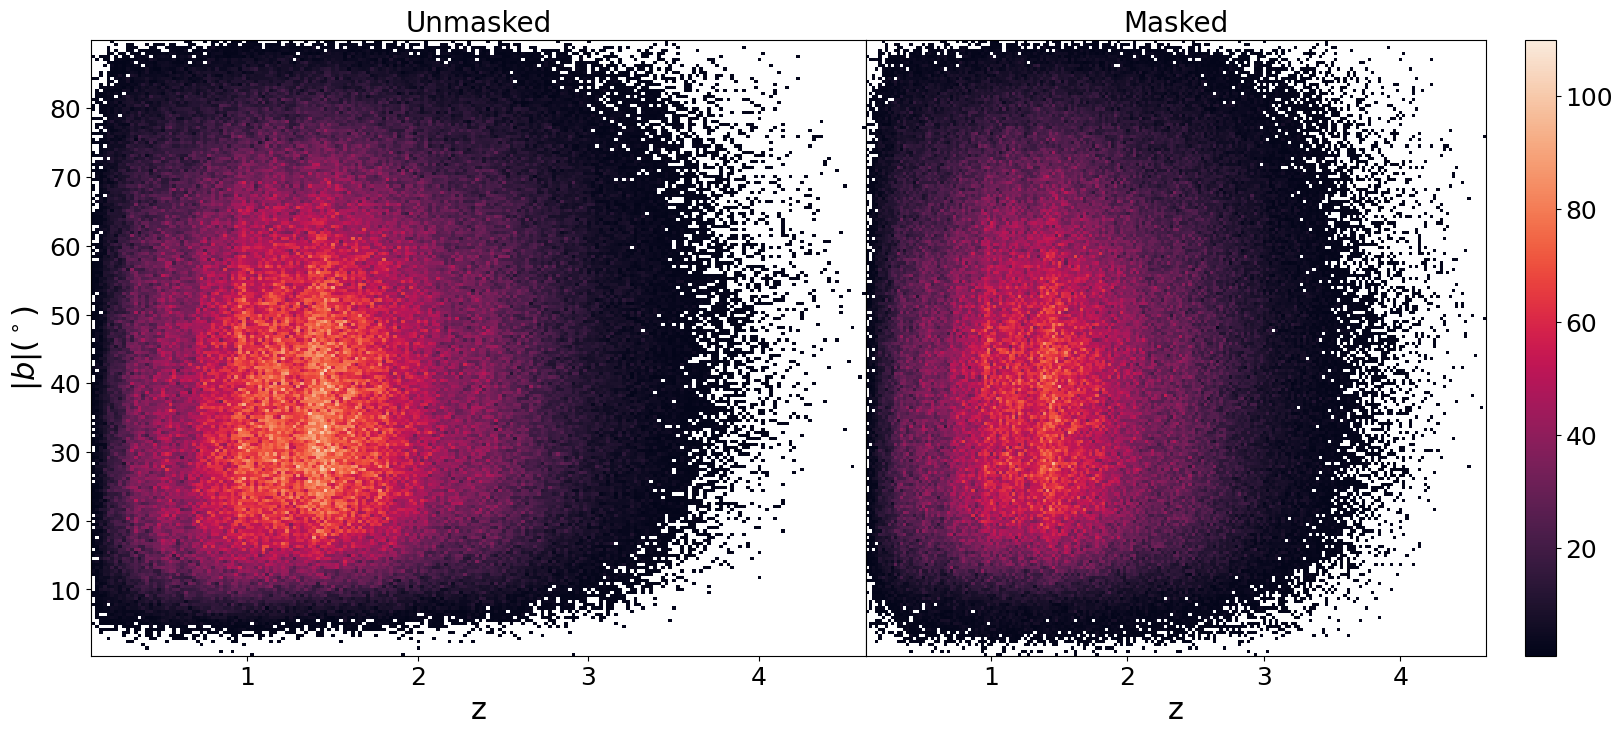

In [44]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
vmax = 110

h1, xedges, yedges, image1 = ax1.hist2d(tab_datalo['redshift_quaia'], np.abs(tab_datalo['b']), label = 'unmasked', bins = 200, 
                                      cmap = cmap, cmin = 1, vmax = vmax)
# plt.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['b'][mask_datalo], label = 'masked')
ax1.set_xlabel('z')
ax1.set_ylabel('$|b| (^\circ)$')
ax1.set_title('Unmasked')
# plt.legend(loc = 'lower center')
# plt.show()

ax2 = fig.add_subplot(gs[1])
# plt.hist2d(tab_datalo['redshift_quaia'], tab_datalo['b'], label = 'unmasked')
h2, xedges, yedges, image2 = ax2.hist2d(tab_datalo['redshift_quaia'][mask_datalo], np.abs(tab_datalo['b'][mask_datalo]), 
                                      label = 'masked', bins = 200, cmap = cmap, cmin = 1, vmax = vmax)
ax2.set_xlabel('z')
# ax2.set_ylabel('$|b| (^\circ)$')
ax2.set_yticks([])
ax2.set_title('Masked')
# plt.legend(loc = 'lower center')

fig.colorbar(image2)

plt.show()

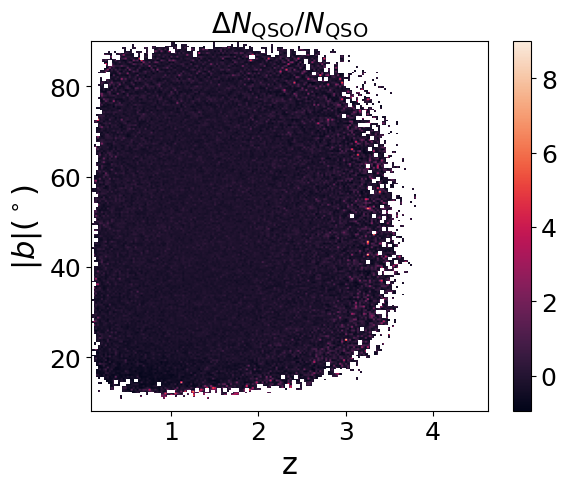

In [45]:
plt.imshow(((h2-h1)/h1).transpose(), cmap = cmap, aspect = 'auto', origin = 'lower', 
           extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]])
plt.xlabel('z')
plt.ylabel('$|b| (^\circ)$')
plt.title('$\Delta N_\mathrm{QSO}/N_\mathrm{QSO}$')
plt.colorbar() # what's left over is high z

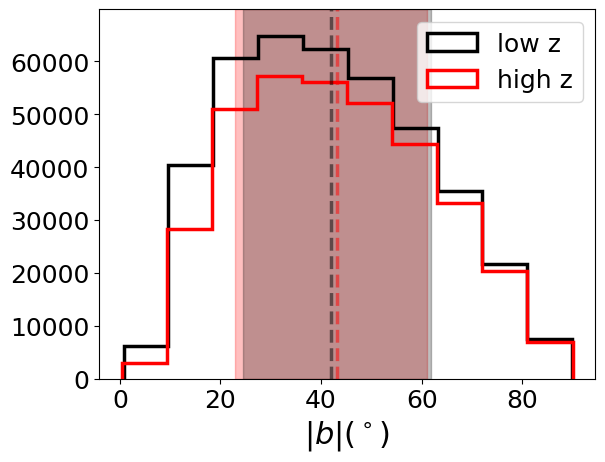

In [46]:
lowz = tab_datalo['redshift_quaia']<np.mean(tab_datalo['redshift_quaia'])
highz = tab_datalo['redshift_quaia']>=np.mean(tab_datalo['redshift_quaia'])
n, bins, patches = plt.hist(np.abs(tab_datalo['b'])[lowz], label = 'low z', color = 'black', histtype = 'step', linewidth = 2.5)
plt.hist(np.abs(tab_datalo['b'])[highz], label = 'high z', color = 'red', histtype = 'step', linewidth = 2.5)
plt.axvline(np.mean(np.abs(tab_datalo['b'])[lowz]), color = 'black', linewidth = 2.5, linestyle = '--', alpha = 0.5)
plt.axvline(np.mean(np.abs(tab_datalo['b'])[highz]), color = 'red', linewidth = 2.5, linestyle = '--', alpha = 0.5)
plt.fill_betweenx(y = np.linspace(0, np.max(n)+5000), 
                  x1 = np.mean(np.abs(tab_datalo['b'])[lowz]) - np.std(np.abs(tab_datalo['b'])[lowz]), 
                  x2 = np.mean(np.abs(tab_datalo['b'])[lowz]) + np.std(np.abs(tab_datalo['b'])[lowz]), alpha = 0.25, color = 'red')
plt.fill_betweenx(y = np.linspace(0, np.max(n)+5000), 
                  x1 = np.mean(np.abs(tab_datalo['b'])[highz]) - np.std(np.abs(tab_datalo['b'])[highz]), 
                  x2 = np.mean(np.abs(tab_datalo['b'])[highz]) + np.std(np.abs(tab_datalo['b'])[highz]), alpha = 0.25, 
                  color = 'black')
plt.legend()
plt.ylim(0, np.max(n)+5000)
plt.xlabel('$|b| (^\circ)$')
plt.show()

In [47]:
def plot_b(xedges, tab_datalo, mask_datalo, ax, title):
    
    bins =  np.linspace(xedges[0], xedges[-1]+0.1)
    ind = np.digitize(tab_datalo['redshift_quaia'], bins)
    
    y = np.array([np.mean(np.abs(tab_datalo['b'])[ind==i+1]) for i in range(len(quaia.recenter(bins)))])
    yerr = [np.std(np.abs(tab_datalo['b'])[ind==i+1]) for i in range(len(quaia.recenter(bins)))]
    
    ind_mask = np.digitize(tab_datalo['redshift_quaia'][mask_datalo], bins)
    
    y_mask = np.array([np.mean(np.abs(tab_datalo['b'])[mask_datalo][ind_mask==i+1]) for i in range(len(quaia.recenter(bins)))])
    yerr_mask = [np.std(np.abs(tab_datalo['b'])[mask_datalo][ind_mask==i+1]) for i in range(len(quaia.recenter(bins)))]
    
    ax.plot(quaia.recenter(bins), y, label = 'unmasked', color = 'black', linewidth = 2.5)
    ax.fill_between(quaia.recenter(bins), y1 = y-yerr, y2 = y+yerr, alpha = 0.25, color = 'black')
    ax.plot(quaia.recenter(bins), y_mask, label = 'masked', color = 'red', linewidth = 2.5, linestyle = '--')
    ax.fill_between(quaia.recenter(bins), y1 = y_mask-yerr_mask, y2 = y_mask+yerr_mask, alpha = 0.25, color = 'red')
    # ax.legend()
    ax.set_xlabel('z')
    # ax.ylabel('$|b| (^\circ)$')
    ax.set_title(title)
    # plt.show()

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3472: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/numpy/core/_methods.py:264: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/numpy/core/_methods.py:222: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/numpy/core/_methods.py:256: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


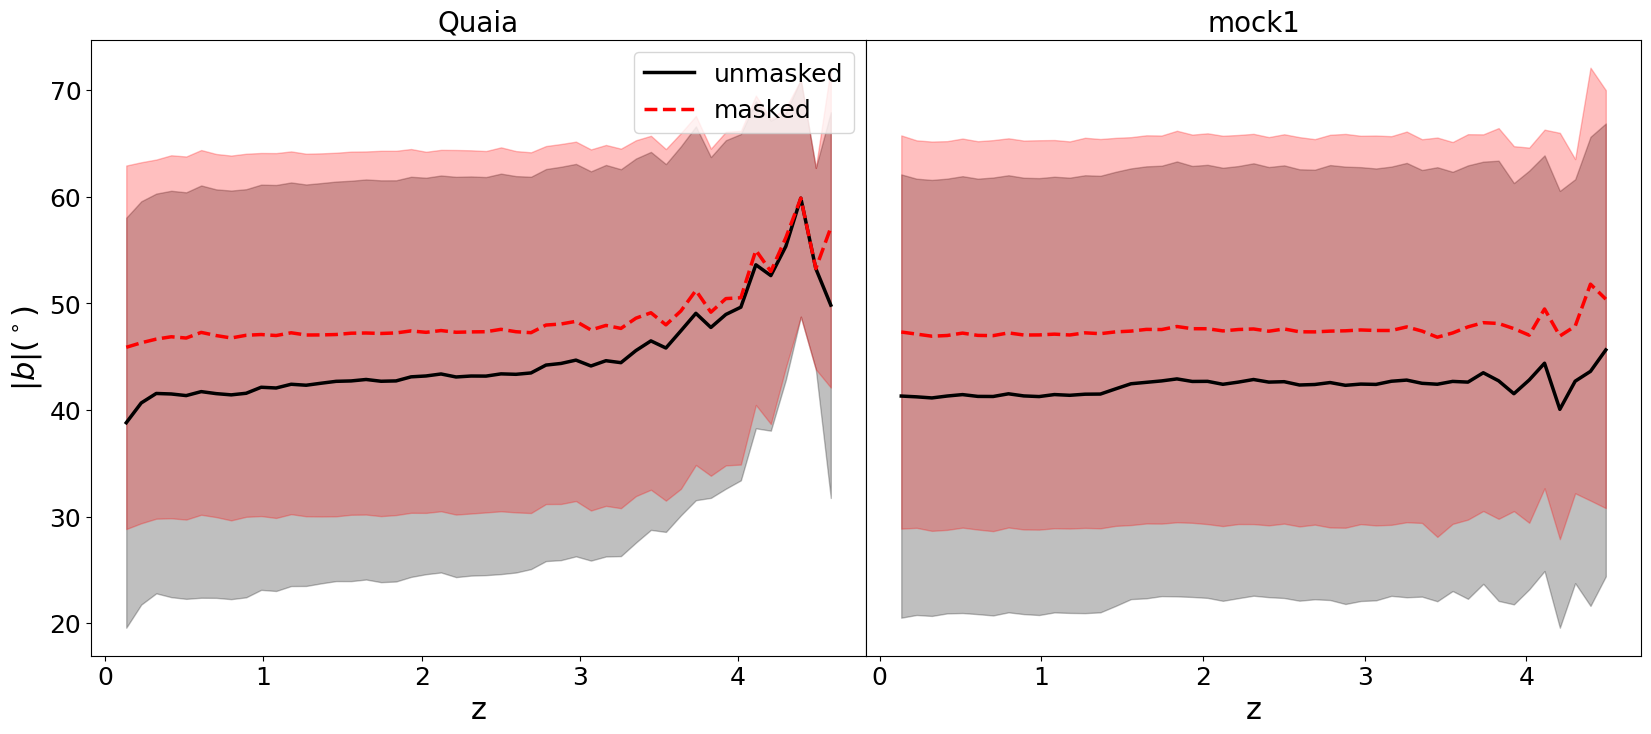

In [48]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
plot_b(xedges, tab_datalo, mask_datalo, ax1, 'Quaia')

ax2 = fig.add_subplot(gs[1])
tab_gcatlo['b'] = np.abs(c_gcatlo.galactic.b.value)
plot_b(xedges, tab_gcatlo, mask_gcatlo, ax2, 'mock1')

ax1.legend()
ax1.set_ylabel('$|b| (^\circ)$')
ax2.set_yticks([])
plt.show()

# Compute the projected angular auto-power spectrum
## First convert redshift space to X, Y, Z coordinates

In [49]:
correction = -5205.182232081812

In [50]:
c = SkyCoord(ra=tab_gcatlo['ra']*u.degree, dec=tab_gcatlo['dec']*u.degree, distance=quaia.comoving_dist(tab_gcatlo['redshift_quaia']))
X1, Y1, Z1 = c.cartesian.xyz.value-correction

## Now measure the pair counts

In [51]:
# Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 180.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'log'

# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 155.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'lin'

In [52]:
nthreads = 18

In [53]:
# refer to https://en.wikipedia.org/wiki/Hubble%27s_law#Dimensionless_Hubble_constant
DD_counts, api_time = theory.DD(autocorr = 1, nthreads = nthreads, binfile = rbins, periodic = False,
                                X1 = X1[mask_gcatlo], Y1 = Y1[mask_gcatlo], Z1 = Z1[mask_gcatlo], 
                                # weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], weight_type='pair_product', 
                                output_ravg = True, c_api_timer = True) # cz/H0 = Mpc/h = m/s * km/1000 m / (100 km/s/Mpc h)
api_time

[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


0.946587

### Generate a $z$ distribution for the random catalog
#### Try interpolating the cdf so it's more smooth

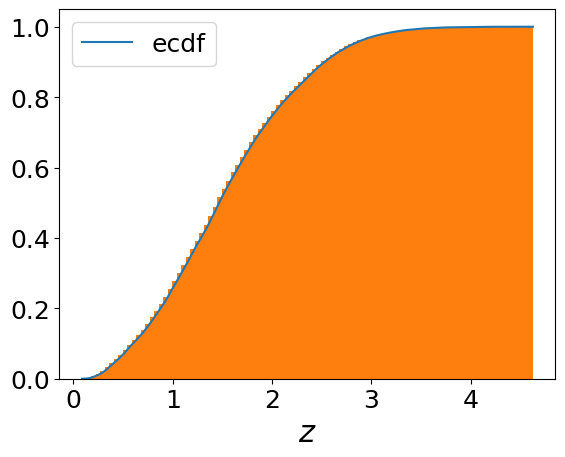

In [54]:
key = quaia.z_dist(tab_datalo, tab_randlo, mask_datalo, mask_randlo, N_datalo_mask, N_randlo_mask, plot = True, b = b, mask_type = mask_type)

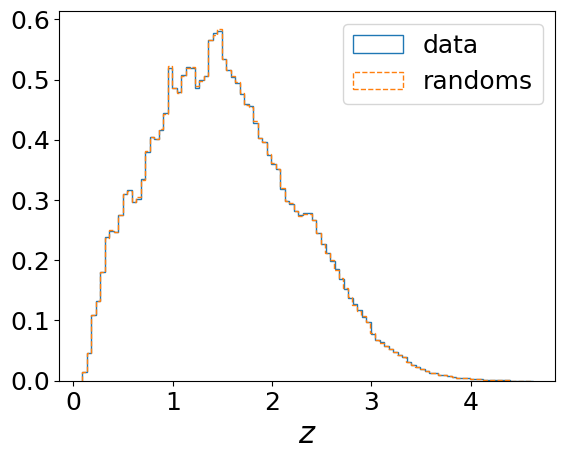

In [55]:
plt.hist(tab_datalo['redshift_quaia'][mask_datalo], histtype = 'step', density = True, label = 'data', bins = 100)
plt.hist(tab_randlo['redshift_quaia_'+key][mask_randlo], histtype = 'step', density = True, label = 'randoms', bins = 100, linestyle = '--')
plt.xlabel('$z$')
plt.legend()
plt.show()

In [56]:
c = SkyCoord(ra=tab_randlo['ra'][mask_randlo], dec=tab_randlo['dec'][mask_randlo], 
             distance=quaia.comoving_dist(tab_randlo['redshift_quaia_'+key][mask_randlo]))
X2, Y2, Z2 = c.cartesian.xyz.value-correction

### Now measure clustering in random catalog

In [57]:
DR_counts, api_time = theory.DD(autocorr = 0, nthreads = nthreads, binfile = rbins, periodic = False,
                                X1 = X1[mask_gcatlo], Y1 = Y1[mask_gcatlo], Z1 = Z1[mask_gcatlo], 
                                # weights1 = 1/selfunc_lo[pixel_indices_gcatlo_mask], 
                                X2 = X2, Y2 = Y2, Z2 = Z2,
                                # weights2 = 1/selfunc_lo[pixel_indices_randlo_mask], weight_type='pair_product', 
                                output_ravg = True, 
                                c_api_timer = True)
api_time

2.510529

In [58]:
RR_counts, api_time = theory.DD(autocorr = 1, nthreads = nthreads, binfile = rbins, periodic = False,
                                X1 = X2, Y1 = Y2, Z1 = Z2, 
                                # weights1 = 1/selfunc_lo[pixel_indices_randlo_mask], weight_type='pair_product',
                                output_ravg = True, c_api_timer = True)
api_time

4.315598

### Plot for sanity check

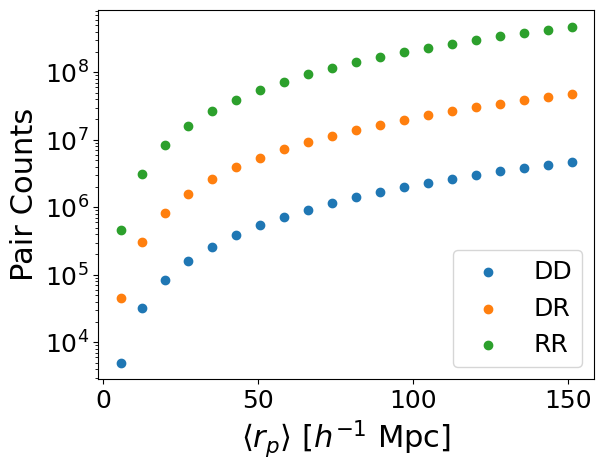

In [59]:
# DD_counts['npairs'] = DD_counts['npairs']*DD_counts['weightavg']
# DR_counts['npairs'] = DR_counts['npairs']*DR_counts['weightavg']
# RR_counts['npairs'] = RR_counts['npairs']*RR_counts['weightavg']

plt.scatter(DD_counts['ravg'], DD_counts['npairs'], label = 'DD')
plt.scatter(DR_counts['ravg'], DR_counts['npairs'], label = 'DR')
plt.scatter(RR_counts['ravg'], RR_counts['npairs'], label = 'RR')
plt.xlabel(r'$\langle r_{p}\rangle$ $[h^{-1}$ Mpc]') # projected
plt.ylabel("Pair Counts")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

### Now convert the 2-D Pair counts into a $xi(r)$


In [60]:
# All the pair counts are done, get the angular correlation function
cf = convert_3d_counts_to_cf(N_gcatlo_mask, N_gcatlo_mask, N_randlo_mask, N_randlo_mask,
                                DD_counts, DR_counts,
                                DR_counts, RR_counts)

/tmp/ipykernel_100648/4265368444.py:8: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-3, 10)


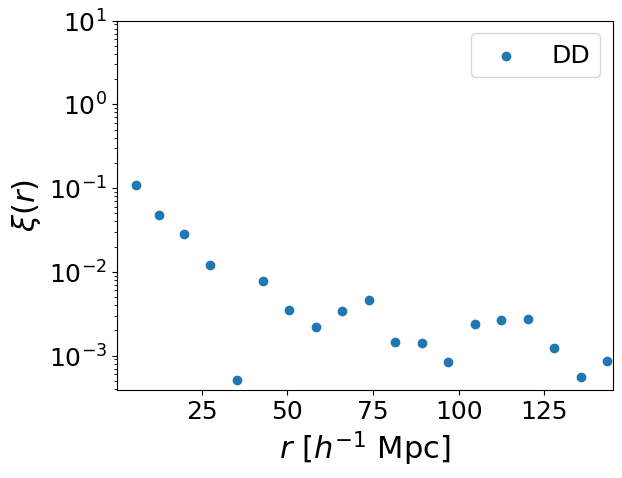

In [61]:
plt.scatter(DD_counts['ravg'], cf, label = 'DD')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylim(-3, 10)
plt.xlim(rmin+0.125, rmax-10)
plt.show()

### Compare to data

In [62]:
cf_mock, ravg_mock = quaia.xi_r(tab_gcatlo[mask_gcatlo], tab_randlo[mask_randlo], 
                                # selfunc_lo, pixel_indices_gcatlo_mask, pixel_indices_randlo_mask, 
                                N_gcatlo_mask, N_randlo_mask, key, RR_counts = RR_counts, nthreads = nthreads, rbins = rbins)

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:506: FutureWarning: elementwise == comparison failed and returning scalar instead; this will raise an error or perform elementwise comparison in the future.
  if RR_counts == None:


In [63]:
cf_data, ravg_data = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], 
                                # selfunc_lo, pixel_indices_datalo_mask, pixel_indices_randlo_mask, 
                                N_datalo_mask, N_randlo_mask, key, RR_counts = RR_counts, nthreads = nthreads, rbins = rbins)

In [64]:
cf_data_test, ravg_data_test = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], 
                                          # selfunc_lo, pixel_indices_datalo_mask, pixel_indices_randlo_mask, 
                                          N_datalo_mask, N_randlo_mask, key, nthreads = nthreads, rbins = rbins)

/tmp/ipykernel_100648/680476642.py:9: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(-1,)


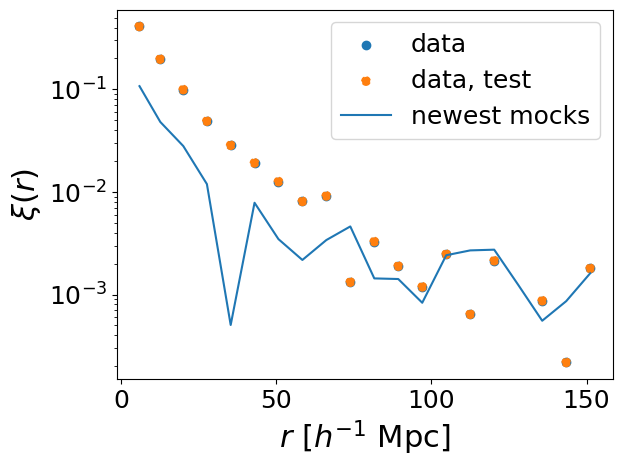

In [65]:
plt.scatter(ravg_data, cf_data, label = 'data')
plt.scatter(ravg_data_test, cf_data_test, label = 'data, test', linestyle = '--')
plt.plot(ravg_mock, cf_mock, label = 'newest mocks')
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.ylim(-1,)
plt.legend()
plt.show()

### Average the mocks

In [66]:
cf_mocks, ravg_mocks = [], []
for i in range(1,31):
    
    fn_gcatlo_i = '../Quaia_mock_catalogs-20250211T213139Z-001/Quaia_mock_catalogs/G20/mock_catalog_quaia_G20_mock{}.fits'.format(str(i))
    tab_gcatlo_i, pixel_indices_gcatlo_mask_i, N_gcatlo_mask_i, mask_gcatlo_i = quaia.read(fn_gcatlo_i, G_lo, fn_sello, b = b, mask_type = mask_type, 
                                                                                           selfunc_lo = selfunc_lo)
    cf_mock_i, ravg_mock_i = quaia.xi_r(tab_gcatlo_i[mask_gcatlo_i], tab_randlo[mask_randlo], 
                                        # selfunc_lo, pixel_indices_gcatlo_mask_i, pixel_indices_randlo_mask, 
                                        N_gcatlo_mask_i, N_randlo_mask, key, RR_counts = RR_counts, nthreads = nthreads,
                                        rbins = rbins)
    cf_mocks.append(cf_mock_i)
    ravg_mocks.append(ravg_mock_i)

Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra','dec','redshift_quaia','redshift_quaia_err')>
Number of data sources: 755512
OrderedDict()
Column names: <TableColumns names=('ra

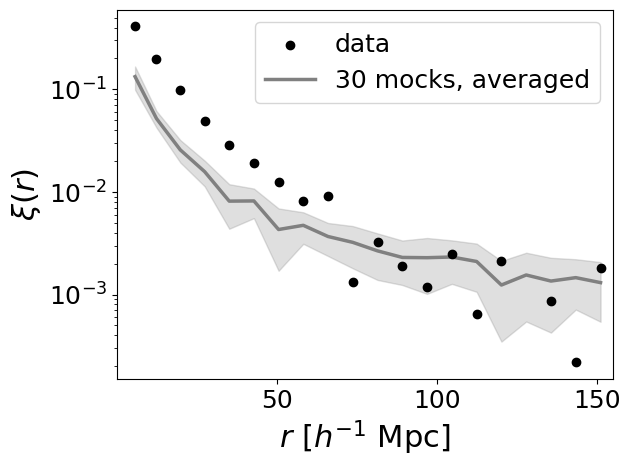

In [67]:
cf_mocks_mean = np.mean(cf_mocks, axis = 0)
ravg_mocks_mean = np.mean(ravg_mocks, axis = 0)
yerr = np.std(cf_mocks, axis = 0)

plt.scatter(ravg_data, cf_data, label = 'data', color = 'black', zorder = 3)
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '30 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)

plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

### Compare to https://arxiv.org/abs/2506.05612
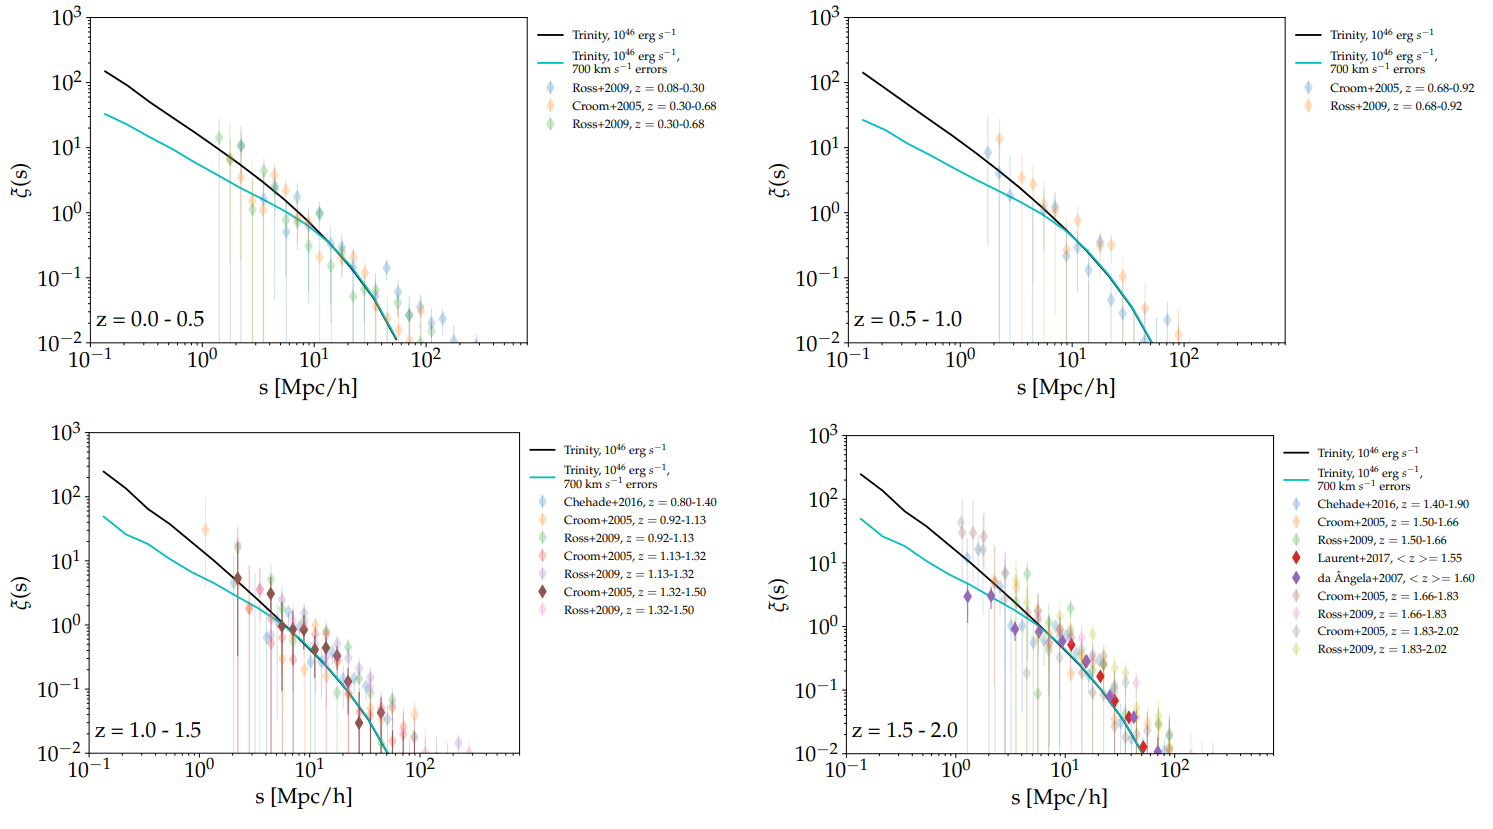

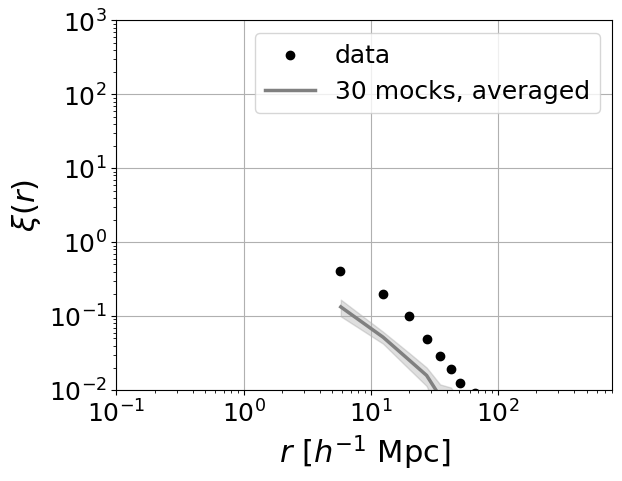

In [68]:
cf_mocks_mean = np.mean(cf_mocks, axis = 0)
yerr = np.std(cf_mocks, axis = 0)

plt.scatter(ravg_data, cf_data, label = 'data', color = 'black', zorder = 3)
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '30 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)

plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-1, 8e2)
plt.ylim(1e-2, 1e3)
plt.legend()
plt.grid()
plt.show()

## Check impact of masking

In [69]:
pixel_indices_randlo = hp.ang2pix(NSIDE, tab_randlo['ra'], tab_randlo['dec'], lonlat=True)

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


...

/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


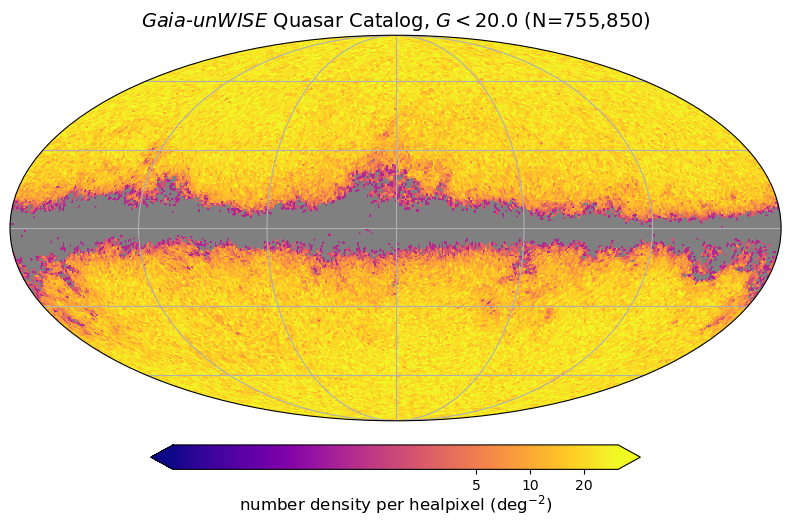

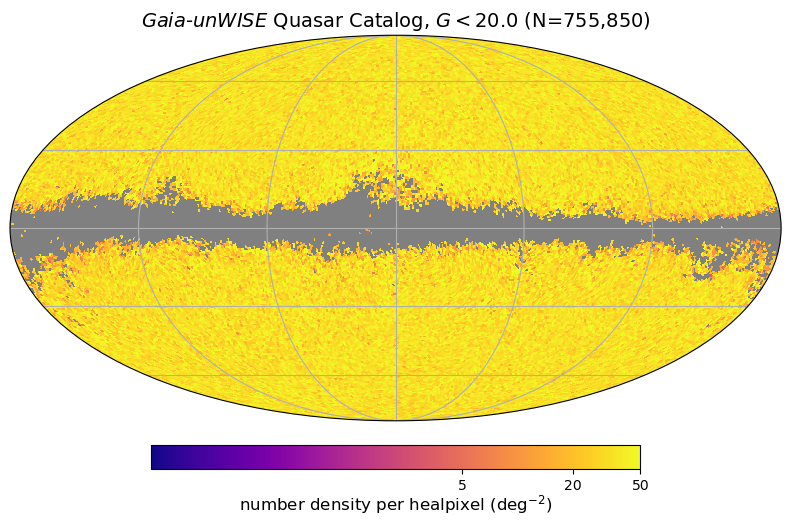

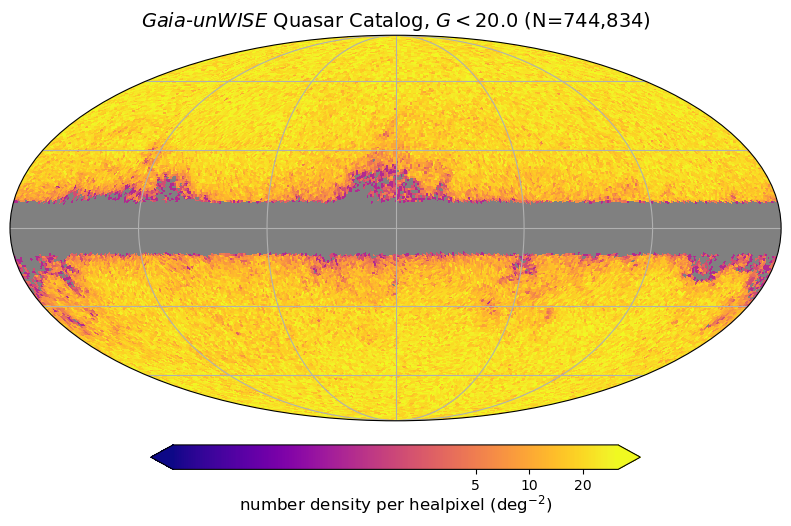

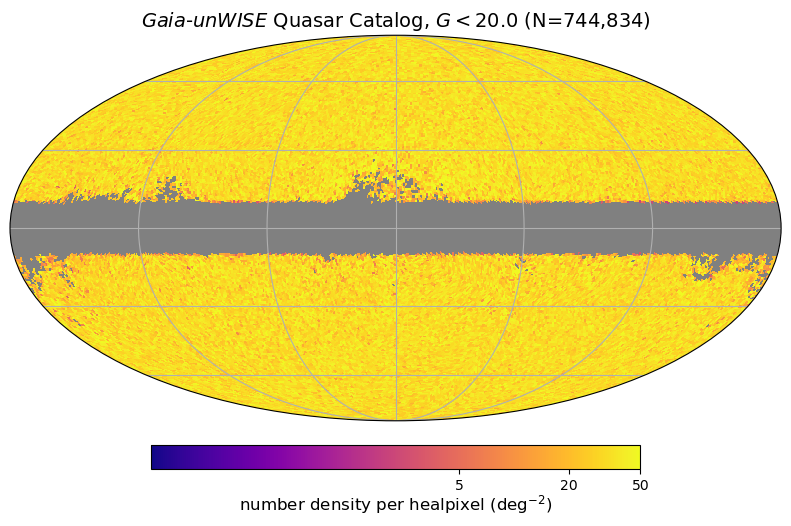

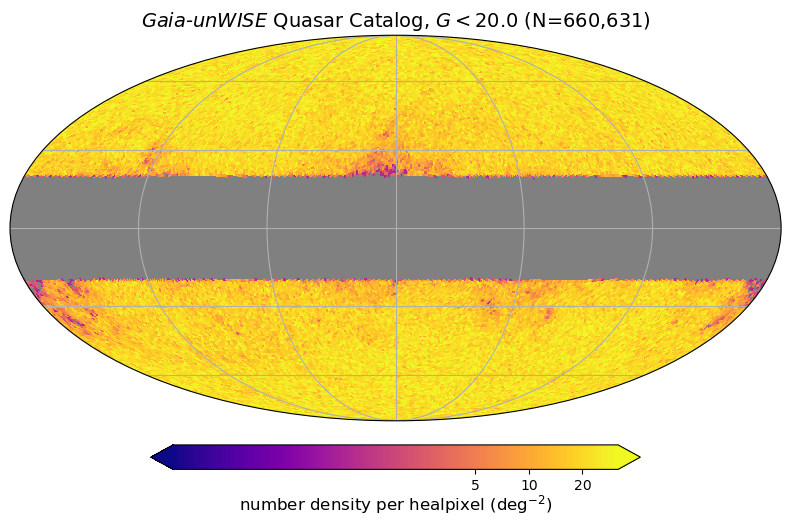

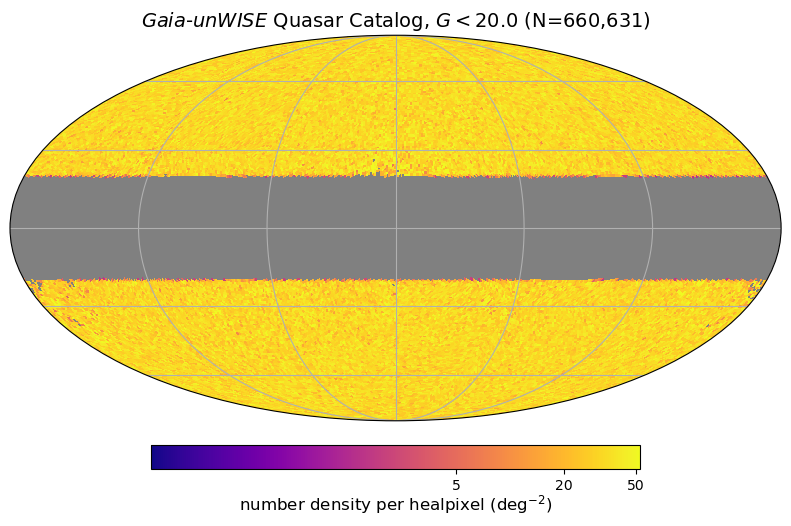

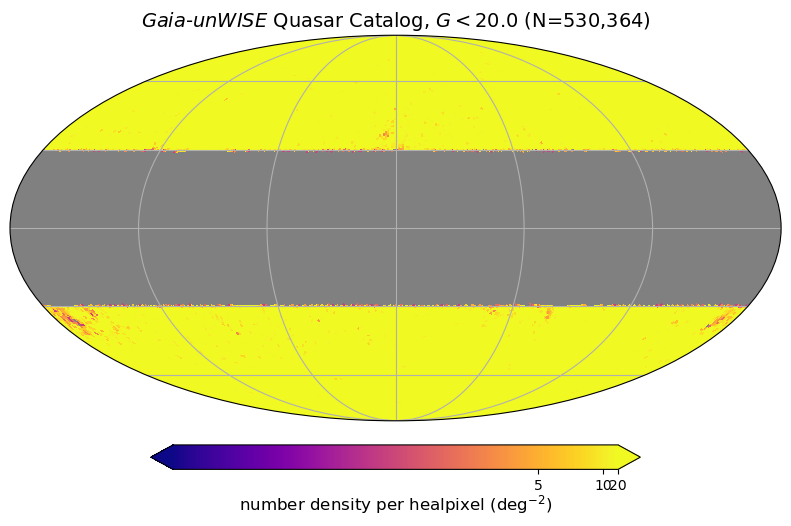

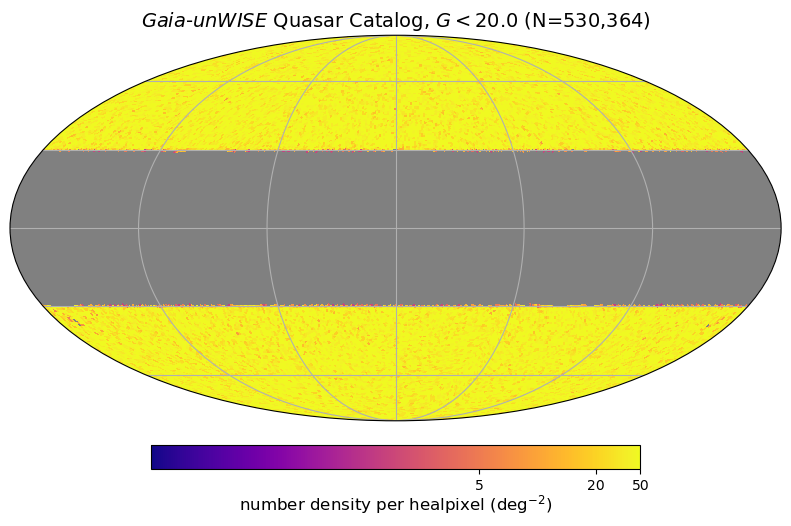

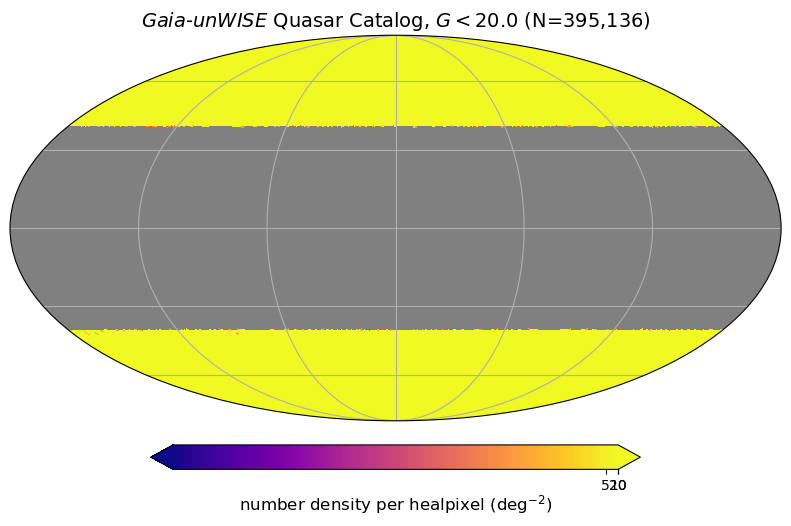

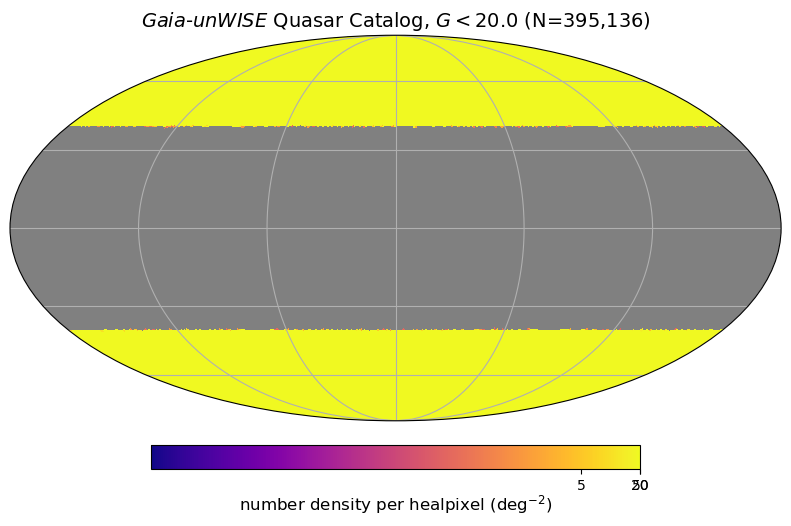

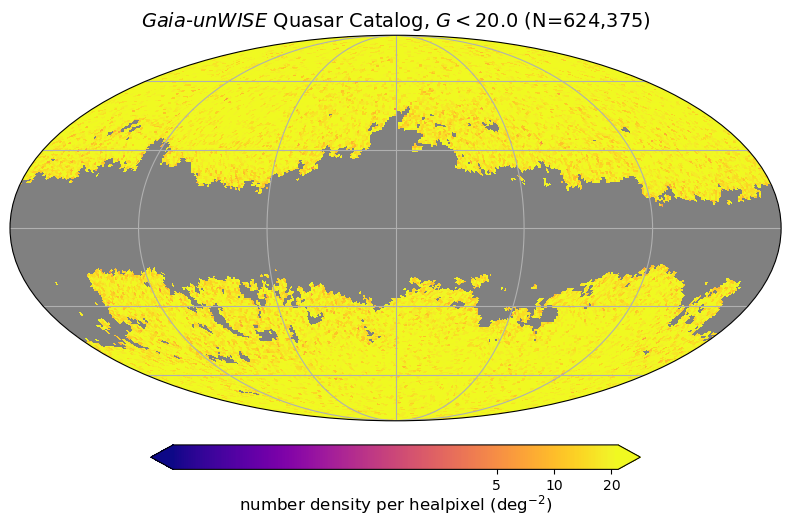

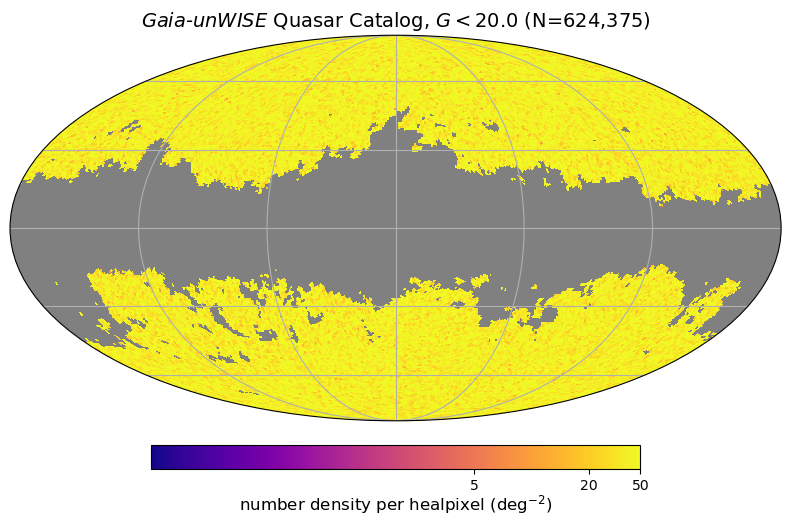

In [70]:
cf_data_b_array, ravg_data_b_array = [], []
b_array = [0, 10, 20, 30, 40, 0]
fac_stdev_array = [1.5, 1.5, 1.45, 0.5, 0.5, 0.5] #1.45, 0.5
mask_type_array = [None, None, None, None, None, 'selfunc']
for i in range(len(b_array)):
    
    _, pixel_indices_datalo_b, N_datalo_b, mask_datalo_b = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, b = b_array[i],
                                                                      mask_type = mask_type_array[i], selfunc_lo = selfunc_lo, plot = True, 
                                                                      fac_stdev = fac_stdev_array[i])

    if mask_type_array[i]==None:
        mask_randlo_b = np.abs(c_randlo.galactic.b.value)>=b_array[i] # use galactic coordinates from data 
        # pixel_indices_randlo_b = hp.ang2pix(NSIDE, tab_randlo['ra'][mask_randlo_b], tab_randlo['dec'][mask_randlo_b], lonlat=True)
    else:
        mask_randlo_b = selfunc_lo[pixel_indices_randlo]>=0.5
        # pixel_indices_randlo_b = pixel_indices_randlo[mask_randlo_b]
        
    N_randlo_b = len(tab_randlo['ra'][mask_randlo_b])
    key_b = quaia.z_dist(tab_datalo, tab_randlo, mask_datalo_b, mask_randlo_b, N_datalo_b, N_randlo_b, b = b_array[i], mask_type = mask_type_array[i])
    
    cf_data_b, ravg_data_b = quaia.xi_r(tab_datalo[mask_datalo_b], tab_randlo[mask_randlo_b], 
                                        # selfunc_lo, pixel_indices_datalo_b, pixel_indices_randlo_b, 
                                        N_datalo_b, N_randlo_b, key_b, nthreads = nthreads, rbins = rbins)
    cf_data_b_array.append(cf_data_b)
    ravg_data_b_array.append(ravg_data_b)

In [71]:
label = ['$b\geq{:d}^{{\circ}}$'.format(b) for b in b_array[:-1]]
label.append('$w_p\geq0.5$')

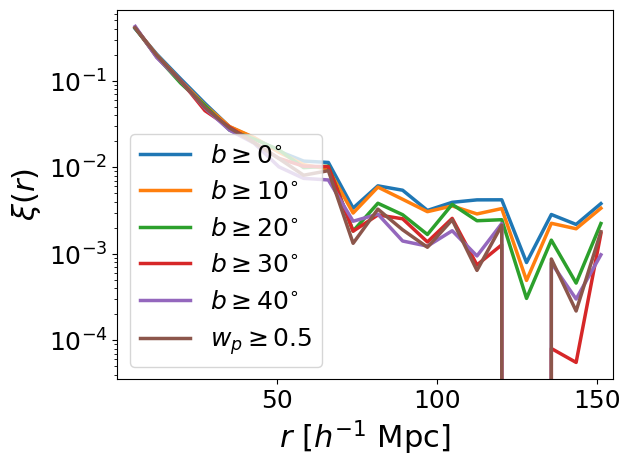

In [72]:
for i in range(len(b_array)):
    plt.plot(ravg_data_b_array[i], cf_data_b_array[i], label = label[i], linewidth = 2.5)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

### Try a selection function-based mask

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/notebooks/quaia.py:108: RuntimeWarning: invalid value encountered in true_divide
  map_selfunc_lo = map_gcatlo/selfunc_lo


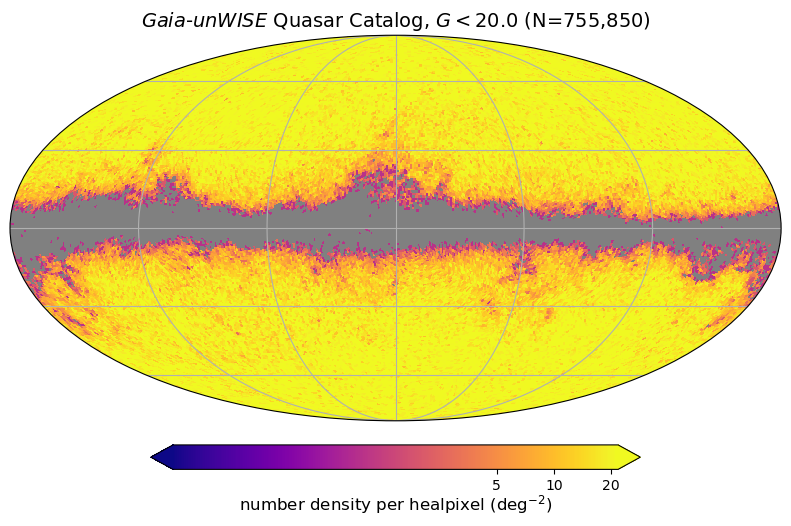

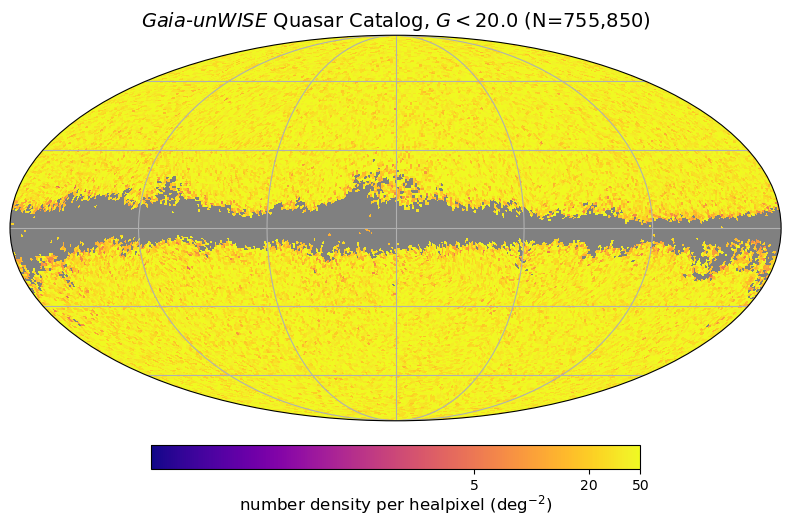

In [73]:
_, pixel_indices_datalo, _, _ = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, b = 0, plot = True, fac_stdev = fac_stdev)

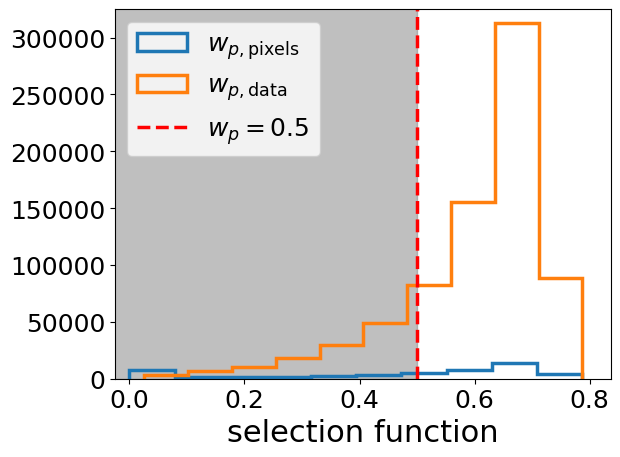

In [74]:
plt.hist(selfunc_lo, label = '$w_{p, \mathrm{pixels}}$', histtype = 'step', linewidth = 2.5)
plt.hist(selfunc_lo[pixel_indices_datalo], label = '$w_{p, \mathrm{data}}$', histtype = 'step', linewidth = 2.5)
plt.axvline(0.5, label = '$w_p=0.5$', linestyle = '--', color = 'red', linewidth = 2.5)
plt.fill_betweenx(np.linspace(0, 350000),-0.205, 0.5, color = 'grey', alpha = 0.5)
plt.xlabel('selection function')
plt.legend()
plt.xlim(-0.025,)
plt.ylim(0, 325000)
plt.show()

## Try not correcting for the selection function

In [75]:
# cf_data_nosel, ravg_data_nosel = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], np.ones_like(selfunc_lo), pixel_indices_datalo_mask, 
#                                             pixel_indices_randlo_mask, N_datalo_mask, N_randlo_mask, key, nthreads = nthreads, 
#                                             rbins = rbins)
cf_data_sel, ravg_data_sel = quaia.xi_r(tab_datalo[mask_datalo], tab_randlo[mask_randlo], N_datalo_mask, N_randlo_mask, key, selfunc_lo = selfunc_lo, 
                                        pixel_indices_gcatlo = pixel_indices_datalo_mask, pixel_indices_randlo = pixel_indices_randlo_mask, 
                                        weight_type = 'pair_product', nthreads = nthreads, rbins = rbins)

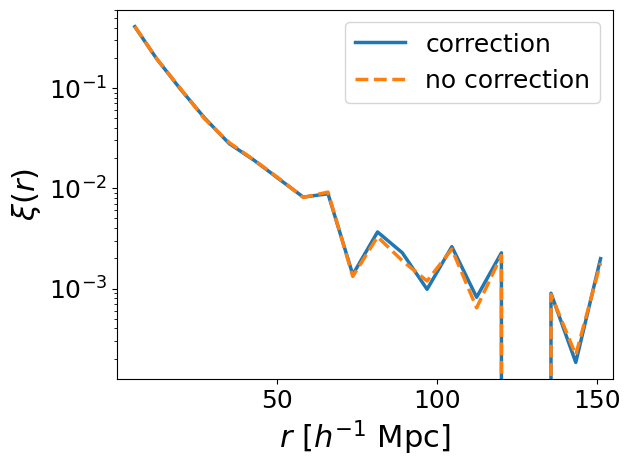

In [76]:
# plt.plot(ravg_data, cf_data, label = 'correction', linewidth = 2.5)
# plt.plot(ravg_data_nosel, cf_data_nosel, label = 'no correction', linestyle = '--', linewidth = 2.5)
plt.plot(ravg_data_sel, cf_data_sel, label = 'correction', linewidth = 2.5)
plt.plot(ravg_data, cf_data, label = 'no correction', linestyle = '--', linewidth = 2.5)
plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
# plt.ylim(-1,)
plt.legend()
plt.show()

## Save points

In [77]:
np.save('../results/xi_ravg_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_data_noweights'.format(scale, rmin, rmax, nbins), ravg_data)
np.save('../results/xi_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_data_noweights'.format(scale, rmin, rmax, nbins), cf_data)

In [78]:
for i in range(1, 31):
    
    np.save('../results/xi_ravg_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_mock{:d}_noweights'.format(scale, rmin, rmax, nbins, i), ravg_mocks[i-1])
    np.save('../results/xi_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_mock{:d}_noweights'.format(scale, rmin, rmax, nbins, i), cf_mocks[i-1])

In [79]:
ravg_data2 = np.load('../results/xi_ravg_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_data_noweights.npy'.format(scale, rmin, rmax, nbins))
cf_data2 = np.load('../results/xi_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_data_noweights.npy'.format(scale, rmin, rmax, nbins))

In [80]:
ravg_mocks2, cf_mocks2 = [], []
for i in range(1, 31):
    
    ravg_mocks2.append(np.load('../results/xi_ravg_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_mock{:d}_noweights.npy'.format(scale, rmin, rmax, nbins, 
                                                                                                                         i)))
    cf_mocks2.append(np.load('../results/xi_{}_rmin{:.1f}_rmax{:.1f}_nbins{:d}_G20_mock{:d}_noweights.npy'.format(scale, rmin, rmax, nbins, i)))

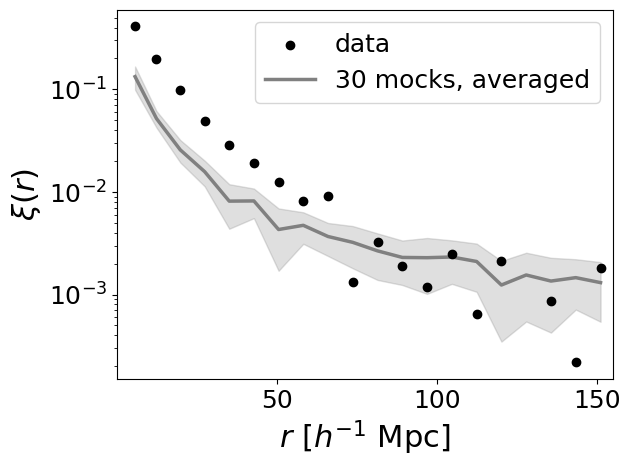

In [81]:
cf_mocks_mean = np.mean(cf_mocks2, axis = 0)
ravg_mocks_mean = np.mean(ravg_mocks2, axis = 0)
yerr = np.std(cf_mocks, axis = 0)

plt.scatter(ravg_data, cf_data, label = 'data', color = 'black', zorder = 3)
plt.plot(ravg_mocks_mean, cf_mocks_mean, color = 'gray', label = '30 mocks, averaged', linewidth = 2.5)
plt.fill_between(ravg_mocks_mean, y1 = cf_mocks_mean - yerr, y2 = cf_mocks_mean + yerr, color = 'gray', alpha = 0.25)

plt.xlabel(r'$r$ $[h^{-1}$ Mpc]') # projected
plt.ylabel(r"$\xi(r)$")
if scale == 'log':
    plt.xscale('log')
plt.yscale('log')
plt.xlim(rmin, rmax)
plt.legend() #(1, 0.25, 0.5, 0.5))
plt.show()

# Questions
- why are npairs higher for lower pimax?
- negative wp? due to DR? bad? --> no sometimes clustering is negative (voids)
- why do they use hubble distance if z is not << 1?
- does wp still get rid of RSDs if we are integrating to pimax and not infinity?
- why does xi_r calculation change every time i run it? --> because of regenerating z's! should it fluctuate that much?
- is it ok that cartesian coordinates go from -x/2 to x/2? --> no?